## **Cyber-twin Smart Meter Nodes based Energy Load Forecasting using Cryptographic Federated Learning and LLM Integration**

**Proposed Method: LSTM based Cryptographic FedAggSum-PredDF (Federated Learning Aggregation via Summational Predicted Data Frame)**

Novelty:
1. Relative Directional LSTM (Redi-LSTM). We can use it for both LSTM, BiLSTM, asnd multi-directional LSTM.
2. AES-HMAC-Fernet Cryptography based Secure Federated Learning Aggregation.
3. Cryptographic FedAggSum-PredDF (Federated Learning Aggregation via Summational Predicted Data Frame)
4. Cryptographic Cyber-twin Smart Meter concept
5. Time-searies comparative analysis between Actual and Predicted for generating risk free (Redusing imbalance/high/low load demand & AI hallucination) energy demand or load forecasting plot,
6. Distributed Generative Energy Load forecasting for Smart-meter users.
7. LLM integration with final output of federated learning for realistic energy demand load forecasting.


In [ ]:
import time

start_time = time.time()

# **Libraries**



In [ ]:
!pip install keras-flops

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap # Explainable AI

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import pickle
import base64
from cryptography.hazmat.primitives import hashes, hmac, padding
from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes
from cryptography.hazmat.backends import default_backend
from io import BytesIO
import pickle

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Layer, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import *

import os
import time
import struct

try:
    from keras_flops import get_flops
except KeyError:
    print("FLOPs already registered; skipping re-import.")



FLOPs already registered; skipping re-import.


# **Functions Section**
**AES-HMAC-Fernet Encryption/Decryption Functions**

In [ ]:
def generate_keys():
    AES_key = os.urandom(16)  # 128-bit AES key
    HMAC_key = os.urandom(32)  # 256-bit HMAC key
    return AES_key, HMAC_key

In [ ]:
def encrypt_dataframe(AES_key, HMAC_key, df):
    # Serialize DataFrame
    plaintext = pickle.dumps(df)

    # Generate IV (AES block size = 16 bytes)
    iv = os.urandom(16)

    # Pad plaintext (PKCS7 for AES block size)
    padder = padding.PKCS7(128).padder()
    padded_data = padder.update(plaintext) + padder.finalize()

    # AES-128-CBC encryption (10 rounds internally)
    cipher = Cipher(algorithms.AES(AES_key), modes.CBC(iv), backend=default_backend())
    encryptor = cipher.encryptor()
    ciphertext = encryptor.update(padded_data) + encryptor.finalize()

    # HMAC-SHA256 (Encrypt-then-MAC)
    h = hmac.HMAC(HMAC_key, hashes.SHA256(), backend=default_backend())
    h.update(iv + ciphertext)
    tag = h.finalize()

    # Return Base64 encoded result
    return base64.b64encode(iv + ciphertext + tag)

In [ ]:
def decrypt_dataframe(AES_key, HMAC_key, encrypted_data):
    data = base64.b64decode(encrypted_data)

    iv = data[:16]
    ciphertext = data[16:-32]
    tag = data[-32:]

    # Verify HMAC first
    h = hmac.HMAC(HMAC_key, hashes.SHA256(), backend=default_backend())
    h.update(iv + ciphertext)
    h.verify(tag)

    # AES decryption
    cipher = Cipher(algorithms.AES(AES_key), modes.CBC(iv), backend=default_backend())
    decryptor = cipher.decryptor()
    padded_plaintext = decryptor.update(ciphertext) + decryptor.finalize()

    # Remove padding
    unpadder = padding.PKCS7(128).unpadder()
    plaintext = unpadder.update(padded_plaintext) + unpadder.finalize()

    # Deserialize DataFrame
    return pickle.loads(plaintext)


**Data Preparation Function for LSTM**

In [ ]:
def prepare_data(df, scaler, look_back):
    # Drop unnecessary columns
    df = df.drop(['LCLid', 'energy_median', 'energy_mean', 'energy_max', 'energy_count', 'energy_std', 'energy_min'], axis=1)

    # Replace blank or missing values in 'energy_sum' kWh with 0
    df['energy_sum'] = df['energy_sum'].fillna(0)

    # (Optional) if there are blanks as empty strings instead of NaN:
    df['energy_sum'] = df['energy_sum'].replace('', 0)

    # Ensure the column is numeric
    df['energy_sum'] = pd.to_numeric(df['energy_sum'], errors='coerce').fillna(0)

    # Convert date format
    df['date'] = pd.to_datetime(df['day'], format='%m/%d/%Y')

    # Rename column
    df = df.rename(columns={'energy_sum': 'Energy_kWh'})

    # Keep only required columns
    df = df[['date', 'Energy_kWh']]

    print(df)

    # Ensure date sorting
    df = df.sort_values('date').reset_index(drop=True)

    # Split data
    train_data = df.iloc[:-40] # all data before last 40 days
    test_data = df.iloc[-40:]  # last 40 days

    # Select target column
    train_values = train_data['Energy_kWh'].astype(float).values.reshape(-1, 1)
    test_values = test_data['Energy_kWh'].astype(float).values.reshape(-1, 1)

    train_scaled = scaler.fit_transform(train_values)
    test_scaled = scaler.transform(test_values)

    # Function to create input sequences
    def create_sequences(dataset, lookback):
        X, y = [], []
        for i in range(len(dataset) - look_back):
            X.append(dataset[i:i+look_back])
            y.append(dataset[i+look_back])
        return np.array(X), np.array(y)

    # Create train and test sequences
    X_train, y_train = create_sequences(train_scaled, look_back)
    X_test, y_test = create_sequences(test_scaled, look_back)

    # Reshape for LSTM input
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    return X_train, y_train, X_test, y_test, df['date'][-40:]

**RelativeDirectional LSTM Function**

This novel LSTM can use as general LSTM, Bi-LSTTM, Relative direction features base multi-directional LSTM

In [ ]:
# -----------------------------
# 4. SimpleBidirectional Layer (like Keras) with RelativeDirectional features
# -----------------------------
class RelativeDirectional(Layer):
    """
    A multi-directional RNN layer, similar to Bidirectional, but supports
    arbitrary directions: forward, backward, left, right, up, down.

    Example:
        RelativeDirectional(LSTM(50, return_sequences=False),
                            directions=['forward','backward','left'],
                            merge_mode='concat')
    """
    VALID_DIRECTIONS = ['forward','backward','left','right','up','down']

    def __init__(self, layer, directions=['forward','backward'], merge_mode='concat', **kwargs):
        super(RelativeDirectional, self).__init__(**kwargs)

        if not set(directions).issubset(self.VALID_DIRECTIONS):
            raise ValueError(f"Invalid directions {directions}. Must be subset of {self.VALID_DIRECTIONS}")

        self.directions = directions
        self.merge_mode = merge_mode
        self.layer_class = layer.__class__
        self.layer_config = layer.get_config()
        self.sub_layers = {}

        # Create a sub-layer for each direction
        for dir in directions:
            config = self.layer_config.copy()
            if dir == 'backward':
                config['go_backwards'] = True
            else:
                config['go_backwards'] = False
            # Other directions are treated as independent LSTM for demo purposes
            self.sub_layers[dir] = self.layer_class.from_config(config)

    def call(self, inputs):
        outputs = []
        for dir in self.directions:
            out = self.sub_layers[dir](inputs)
            outputs.append(out)

        # Merge outputs
        if self.merge_mode == 'concat':
            return tf.concat(outputs, axis=-1)
        elif self.merge_mode == 'sum':
            merged = outputs[0]
            for out in outputs[1:]:
                merged = merged + out
            return merged
        elif self.merge_mode == 'ave':
            merged = outputs[0]
            for out in outputs[1:]:
                merged = merged + out
            return merged / len(outputs)
        elif self.merge_mode == 'mul':
            merged = outputs[0]
            for out in outputs[1:]:
                merged = merged * out
            return merged
        else:
            raise ValueError("Invalid merge_mode")
# -----------------------------


In [ ]:
# LSTM Model function
def create_lstm_model(look_back):
    model = Sequential()
    model.add(RelativeDirectional(LSTM(50, return_sequences=False),
                              directions=['forward','backward'],
                              merge_mode='concat',
                              input_shape=(look_back,1)))
    model.add(Dropout(0.2))
    model.add(Dense(1))  # single-step prediction
    model.compile(loss='mse', optimizer='adam', metrics=['mae', 'accuracy'])

    return model

In [ ]:
def local_train(model, X_train, y_train, X_test, y_test):
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[EarlyStopping(monitor='val_loss', patience=25)],
        verbose=2,
        shuffle=False
    )
    return history

In [ ]:
# Forecasting helper
def forecast(model, X, scaler):
    pred_scaled = model.predict(X)
    pred = scaler.inverse_transform(pred_scaled)
    return pred

# **Edge Smart-Meter Nodes with CSV Data**

In [ ]:
# Upload your CSVs in Colab first
from google.colab import files
uploaded = files.upload()

df1 = pd.read_csv("Block_0_MAC000002.csv") # smart_meter_1 ID: MAC000002
df2 = pd.read_csv("Block_0_MAC000246.csv") # smart_meter_2 ID: MAC000246
# Here Block_0 is AMI server node

Saving Block_0_MAC000002.csv to Block_0_MAC000002 (1).csv
Saving Block_0_MAC000246.csv to Block_0_MAC000246 (1).csv


In [ ]:
# Print the number of rows and columns in the data
print('Edge Smart Meter Node 1, Smart-meter ID: MAC000002')
print('Number of rows and columns:', df1.shape)

# Display the first 5 rows of the data
df1.head(5)

Edge Smart Meter Node 1, Smart-meter ID: MAC000002
Number of rows and columns: (505, 9)


,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
0,MAC000002,10/12/2012,0.1385,0.154304,0.886,46,0.196034,7.098,0.000
1,MAC000002,10/13/2012,0.1800,0.230979,0.933,48,0.192329,11.087,0.076
2,MAC000002,10/14/2012,0.1580,0.275479,1.085,48,0.274647,13.223,0.070
3,MAC000002,10/15/2012,0.1310,0.213688,1.164,48,0.224483,10.257,0.070
4,MAC000002,10/16/2012,0.1450,0.203521,0.991,48,0.184115,9.769,0.087


In [ ]:
# Print the number of rows and columns in the data
print('Edge Smart Meter Node 2, Smart-meter ID: MAC000246')
print('Number of rows and columns:', df2.shape)

# Display the first 5 rows of the data
df2.head(5)

Edge Smart Meter Node 2, Smart-meter ID: MAC000246
Number of rows and columns: (819, 9)


,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
0,MAC000246,12/3/2011,0.1150,0.300233,1.179,30,0.361231,9.007,0.047
1,MAC000246,12/4/2011,0.1750,0.432563,1.914,48,0.484152,20.763,0.026
2,MAC000246,12/5/2011,0.0780,0.125417,0.934,48,0.153327,6.020,0.025
3,MAC000246,12/6/2011,0.1140,0.277542,1.216,48,0.313399,13.322,0.027
4,MAC000246,12/7/2011,0.1035,0.188792,0.873,48,0.209613,9.062,0.026


# **Key Generation at AMI Server Node**

In [ ]:
AES_key, HMAC_key = generate_keys()
print("Keys generated at AMI server.")

Keys generated at AMI server.


# **Data Encrypted and stored at Cyber-Twin Smart-Meter Nodes**

In [ ]:
cyber_twins = {
    "meter1": encrypt_dataframe(AES_key, HMAC_key, df1),
    "meter2": encrypt_dataframe(AES_key, HMAC_key, df2)
}
print("Data encrypted and stored at cyber-twin nodes.")

Data encrypted and stored at cyber-twin nodes.


# **Cyber-Twin Node 1: Local Training, Encryption, and Load Forecasting Plot**

In [ ]:
# Decrypt data for computation
df1_decrypted = decrypt_dataframe(AES_key, HMAC_key, cyber_twins["meter1"])

In [ ]:
df1_decrypted.head(5)

,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
0,MAC000002,10/12/2012,0.1385,0.154304,0.886,46,0.196034,7.098,0.000
1,MAC000002,10/13/2012,0.1800,0.230979,0.933,48,0.192329,11.087,0.076
2,MAC000002,10/14/2012,0.1580,0.275479,1.085,48,0.274647,13.223,0.070
3,MAC000002,10/15/2012,0.1310,0.213688,1.164,48,0.224483,10.257,0.070
4,MAC000002,10/16/2012,0.1450,0.203521,0.991,48,0.184115,9.769,0.087


In [ ]:
scaler1 = MinMaxScaler(feature_range=(0, 1))
look_back1 = 3 #time_step for local LSTM computation
X_train1, y_train1, X_test1, y_test1, dates1 = prepare_data(df1_decrypted, scaler1, look_back1)

          date  Energy_kWh
0   2012-10-12       7.098
1   2012-10-13      11.087
2   2012-10-14      13.223
3   2012-10-15      10.257
4   2012-10-16       9.769
..         ...         ...
500 2014-02-24      12.528
501 2014-02-25      11.826
502 2014-02-26      12.328
503 2014-02-27      20.518
504 2014-02-28       1.387

[505 rows x 2 columns]


In [ ]:
model1 = create_lstm_model(look_back1)

/tmp/ipython-input-745509497.py:17: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(RelativeDirectional, self).__init__(**kwargs)


In [ ]:
history_sm1 = local_train(
    model1,
    X_train1, y_train1,
    X_test1, y_test1
)

Epoch 1/50
15/15 - 6s - 396ms/step - accuracy: 0.0022 - loss: 0.0430 - mae: 0.1734 - val_accuracy: 0.0000e+00 - val_loss: 0.0289 - val_mae: 0.1334
Epoch 2/50
15/15 - 0s - 9ms/step - accuracy: 0.0022 - loss: 0.0107 - mae: 0.0756 - val_accuracy: 0.0000e+00 - val_loss: 0.0147 - val_mae: 0.0916
Epoch 3/50
15/15 - 0s - 9ms/step - accuracy: 0.0022 - loss: 0.0102 - mae: 0.0777 - val_accuracy: 0.0000e+00 - val_loss: 0.0166 - val_mae: 0.0857
Epoch 4/50
15/15 - 0s - 10ms/step - accuracy: 0.0022 - loss: 0.0089 - mae: 0.0640 - val_accuracy: 0.0000e+00 - val_loss: 0.0170 - val_mae: 0.0870
Epoch 5/50
15/15 - 0s - 9ms/step - accuracy: 0.0022 - loss: 0.0087 - mae: 0.0649 - val_accuracy: 0.0000e+00 - val_loss: 0.0158 - val_mae: 0.0849
Epoch 6/50
15/15 - 0s - 9ms/step - accuracy: 0.0022 - loss: 0.0085 - mae: 0.0644 - val_accuracy: 0.0000e+00 - val_loss: 0.0164 - val_mae: 0.0858
Epoch 7/50
15/15 - 0s - 9ms/step - accuracy: 0.0022 - loss: 0.0089 - mae: 0.0638 - val_accuracy: 0.0000e+00 - val_loss: 0.0161 

In [ ]:
pred1 = forecast(model1, X_test1, scaler1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 485ms/step


In [ ]:
# Create a DataFrame for actual and predicted values
predicted_df1 = pd.DataFrame(data={'Actual': scaler1.inverse_transform(y_test1.reshape(-1, 1)).flatten(),
                                   'Predicted': pred1.flatten()},
                            index=df1_decrypted.index[-len(y_test1):])

# Select the last 30 days
predicted_df1_last_30_days = predicted_df1.tail(30)

In [ ]:
predicted_df1_last_30_days = predicted_df1_last_30_days.reset_index(drop=True)

**Encrypting Predicted-DataFrame for Federated Learning Aggregation Process**

In [ ]:
predicted_df1_encrypted = encrypt_dataframe(AES_key, HMAC_key, predicted_df1_last_30_days)
print("Predicted DataFrame encrypted at cyber-twin node.")
print(predicted_df1_encrypted)

Predicted DataFrame encrypted at cyber-twin node.
b'O/VharltGCJRoS58DZoDjOJoslxnbuFG2UwngpsjN3EgXaPljDz55zJJcjk+W3wyfDxYdG9BehYt7XM3TiyTIQ3x7QIgtK084uWBYB5cdTr53f0jc0Bcs3yDmgtd7MYoLXdEnTpSPE08PIqgvO+u3+ET5NdN/2gOULo5lo6XP3A7Sevm1R6N9rVBZzycJwzud8b3S5XokZZUNgAjm725rxySiUzx1fYMvuIbfaytPsQaH67RwPsg7CSZsGmqyYtuSVAic6P8u9sMu18XMLXpqbKWo58hwRKQbDQrQ6MJnu/2BZ8W4Oj+zyTjHcOqkgt4pZgwdNJnpjTT2FBgIwDdhrupojDUYM2XLcDY6zjObH93SP/GY1leTiMOHQ+/jXF7/dZap1kDP5BBwf+kKumDq9MPbeCtrA6SeASlk+Az9+xFQf573YI4vX4idgiVXD0By7CdKySElzgGnk4Vp10rjcTWw70aVC8hDM5nkQ+XK104O1zjQZK2vqPqizdoyA+Bdk+6Pr91/ilEQLeCDlHA4gwpGwXZceEowyxTfDyz5kEjjkvMVdHVSr1sDBoiCXad/5SCGlezCOpJ0dUehoiSadHCsv7uC4rT3Vfvp7BcNVdW4fHdEdoTqZHzssQ6pA6ICS8VVT07a4TqkDhmf/IOwUsBjHNQKPkO8OGHEB1ZVn0qYGagFDRdwJmeVDimMEHPcYPyUeQ+O4xHYzacMgMFZZ5HhtYaSGXbgi0XL6kKRKbLU+hmASslZDhkyAZLRp/kl6slvS9fD6uag16UHekY8pKHYTPb3vldUrRo3/amGvl5O3+GIVGjRve0ckpIlSXlA/lUpX7sTNQrjoDYibSUZrSF2HCMAYMBV7R7Auv29ADwqyfzE2SSn6RL4agmHr2S0mKPIYd5pZbHmMZ7YOKybfry19iWRRchpHUFBZcngAwEROAM1CZK

**Load Forecasting for individual Smart-meter user**



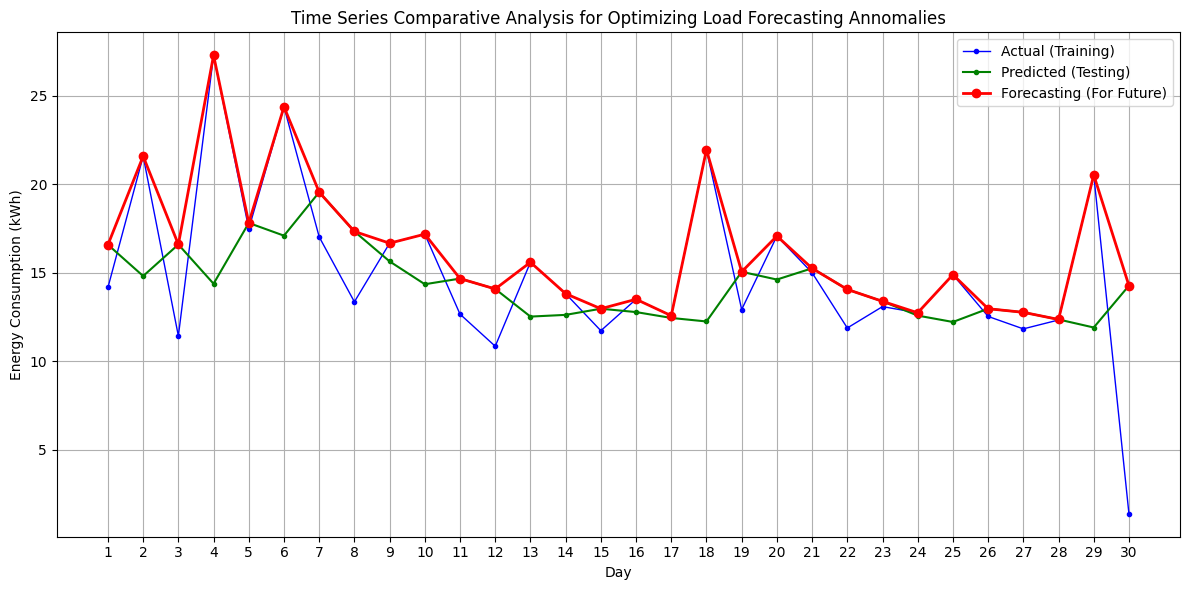

In [ ]:
last_30_days = predicted_df1_last_30_days
assert 'Actual' in predicted_df1_last_30_days.columns and 'Predicted' in last_30_days.columns, \
    "Columns 'Actual' and 'Predicted' must exist in last_30_days"

# Calculate the element-wise maximum between Actual and Predicted
#Time Series Comparative Analysis for Optimizing Load Forecasting Annomalies: Over or Lower or Imbalance Estimation of Demand
forecasting_30_days = pd.DataFrame({
    'Forecasting': last_30_days[['Actual', 'Predicted']].max(axis=1)
})

# Generate x-axis labels (1 to N)
x_labels = range(1, len(last_30_days) + 1)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(x_labels, last_30_days['Actual'], marker='.', label='Actual (Training)', color='blue', linewidth=1)
plt.plot(x_labels, last_30_days['Predicted'], marker='.', label='Predicted (Testing)', color='green', linewidth=1.5)
plt.plot(x_labels, forecasting_30_days['Forecasting'], marker='o', label='Forecasting (For Future)', color='red', linewidth=2)

# Style
plt.xticks(x_labels)
plt.grid(True)
plt.xlabel('Day')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.title('Time Series Comparative Analysis for Optimizing Load Forecasting Annomalies')
plt.tight_layout()
plt.show()

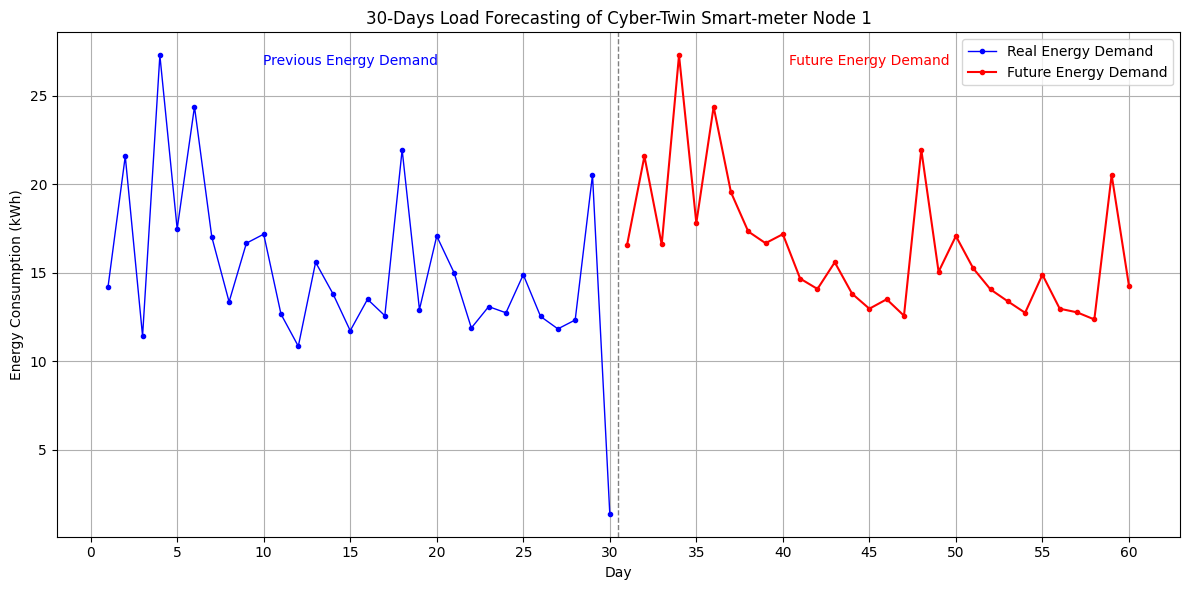

In [ ]:
# Create a new combined DataFrame
combined_df = pd.DataFrame({
    'Combined': pd.concat([last_30_days['Actual'], forecasting_30_days['Forecasting']], ignore_index=True)
})

# Create x-axis labels for 60 days
x_labels = range(1, len(combined_df) + 1)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(x_labels[:30], combined_df['Combined'][:30], marker='.', color='blue', label='Real Energy Demand', linewidth=1)
plt.plot(x_labels[30:], combined_df['Combined'][30:], marker='.', color='red', label='Future Energy Demand', linewidth=1.5)

# Add vertical separator between the two periods
plt.axvline(x=30.5, color='gray', linestyle='--', linewidth=1)
plt.text(15, combined_df['Combined'].max()*0.98, 'Previous Energy Demand', ha='center', color='blue', fontsize=10)
plt.text(45, combined_df['Combined'].max()*0.98, 'Future Energy Demand', ha='center', color='red', fontsize=10)

# Style
plt.grid(True)
plt.xticks(range(0, 61, 5))
plt.xlabel('Day')
plt.ylabel('Energy Consumption (kWh)')
plt.title('30-Days Load Forecasting of Cyber-Twin Smart-meter Node 1')
plt.legend()
plt.tight_layout()
plt.show()

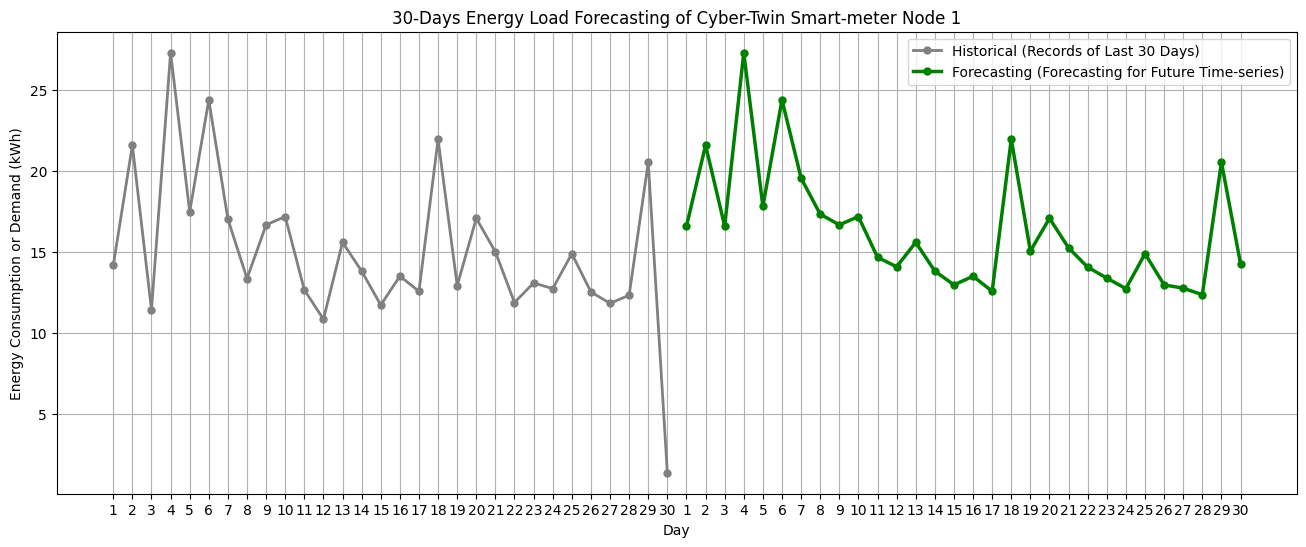

In [ ]:
# Generate a sequence of numbers for x-axis labels starting from 1
x_labels_last = range(1, len(last_30_days) + 1)

# Prepare data for next 30 days
x_labels_future = range(len(last_30_days) + 1, len(last_30_days) + 31)

# Plotting
plt.figure(figsize=(16, 6))
plt.plot(x_labels_last, last_30_days['Actual'], linewidth=2, marker='.', label='Historical (Records of Last 30 Days)', color='gray', markersize=10)
plt.plot(x_labels_future, forecasting_30_days['Forecasting'], linewidth=2.5, marker='.', label='Forecasting (Forecasting for Future Time-series)', color='green', markersize=10)


# Set x-ticks to include both ranges
plt.xticks(list(range(1, 31)) + list(range(31, 61)),
           list(range(1, 31)) + list(range(1, 31)))

# Set x-ticks to include both ranges
#plt.xticks(list(x_labels_last) + list(x_labels_future), list(range(1, len(last_30_days) + 1)) + list(range(len(last_30_days) + 1, len(last_30_days) + 31)))


# Set x-ticks to match the day labels
#plt.xticks(x_labels, fontsize=12)

# Add grid
plt.grid(True)

# Set labels and title
plt.xlabel('Day')
plt.ylabel('Energy Consumption or Demand (kWh)')
plt.legend()
plt.title('30-Days Energy Load Forecasting of Cyber-Twin Smart-meter Node 1')

# Show the plot
plt.show()

Train Loss (MSE): 0.01
Test Loss (MSE): 0.016
Mean Squared Error (MSE): 0.013
MSE based Accuracy: 99.987 %


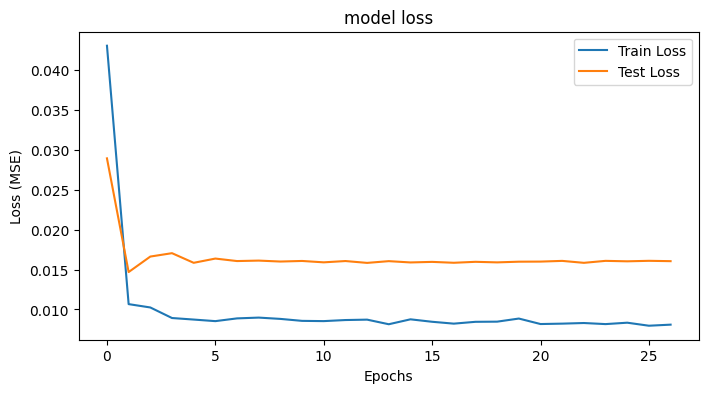

In [ ]:
# Mean Squared Error (MSE) Calculation

#MSE calculation for Regression Task

losses = history_sm1.history['loss']
val_losses = history_sm1.history['val_loss']

# Calculate the average loss across all epochs

average_loss = np.mean(losses)
print("Train Loss (MSE):", round(average_loss, 3)) #mse

# Calculate the average loss across all epochs
average_val_loss = np.mean(val_losses)
print("Test Loss (MSE):",round(average_val_loss, 3)) #mse

# Calculate overall MSE (simple average)
overall_mse = (average_loss + average_val_loss) / 2
print("Mean Squared Error (MSE):", round(overall_mse, 3))

accuracy = 100 - overall_mse
print("MSE based Accuracy:", round(accuracy, 3), "%")

plt.figure(figsize=(8,4))
plt.plot(history_sm1.history['loss'], label='Train Loss')
plt.plot(history_sm1.history['val_loss'], label='Test Loss')
plt.title('model loss')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epochs')
plt.legend(loc='upper right')
plt.show();

Root Mean Squared Error (RMSE): 0.115
RMSE based Accuracy: 99.885 %


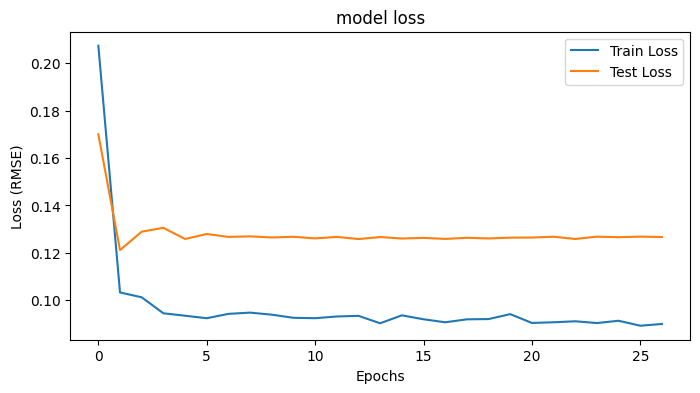

In [ ]:
# Calculate RMSE
rmse_value = np.sqrt(overall_mse)

print("Root Mean Squared Error (RMSE):", round(rmse_value, 3))
accuracy = 100 - rmse_value
print("RMSE based Accuracy:", round(accuracy, 3), "%")

sqrt_rmse_losses = np.sqrt(history_sm1.history['loss'])
sqrt_rmse_val_losses = np.sqrt(history_sm1.history['val_loss'])

plt.figure(figsize=(8,4))
plt.plot(sqrt_rmse_losses, label='Train Loss')
plt.plot(sqrt_rmse_val_losses, label='Test Loss')
plt.title('model loss')
plt.ylabel('Loss (RMSE)')
plt.xlabel('Epochs')
plt.legend(loc='upper right')
plt.show();

Training MAE:  0.068
Validation or Test MAE:  0.089
Overall MAE (Simple Average): 0.078
MAE based Accuracy: 99.92175985872746 %


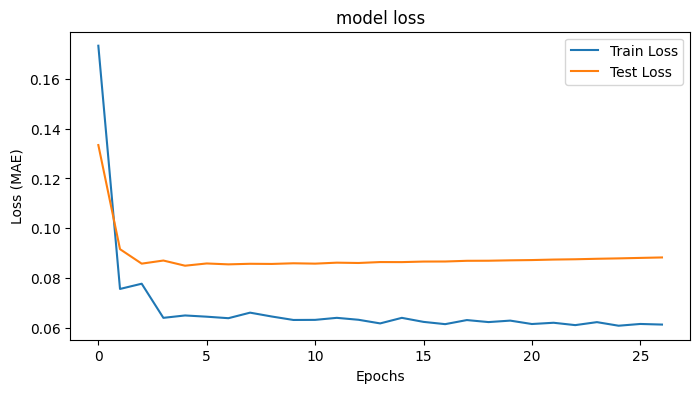

In [ ]:
# Mean Absolute Error (MSE) Calculation
mae_train = history_sm1.history['mae']          # MAE for training set
mae_test = history_sm1.history['val_mae']
average_mae_train = np.mean(mae_train)
average_mae_test = np.mean(mae_test)
print("Training MAE: ", round(average_mae_train, 3))
print(f"Validation or Test MAE: ",  round(average_mae_test, 3))

overall_mae = (average_mae_train + average_mae_test) / 2
print(f"Overall MAE (Simple Average): {overall_mae:.3f}")

accuracy = 100 - overall_mae
print("MAE based Accuracy:", accuracy, "%")

plt.figure(figsize=(8,4))
plt.plot(history_sm1.history['mae'], label='Train Loss')
plt.plot(history_sm1.history['val_mae'], label='Test Loss')
plt.title('model loss')
plt.ylabel('Loss (MAE)')
plt.xlabel('Epochs')
plt.legend(loc='upper right')
plt.show();

In [ ]:
Overall_accuracy_score = (overall_mae+rmse_value+overall_mse)/3
print("accuracy score for cyber-twin node 1:", Overall_accuracy_score)
accuracy_per = 100 - Overall_accuracy_score
print("Accuracy:", round(accuracy_per, 3), "%")

accuracy score for cyber-twin node 1: 0.06879214850605354
Accuracy: 99.931 %


# **Cyber-Twin Node 2: Local Training, Encryption, and Load Forecasting Plot**

In [ ]:
# Decrypt data for computation
df2_decrypted = decrypt_dataframe(AES_key, HMAC_key, cyber_twins["meter2"])
df2_decrypted.head(5)

,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
0,MAC000246,12/3/2011,0.1150,0.300233,1.179,30,0.361231,9.007,0.047
1,MAC000246,12/4/2011,0.1750,0.432563,1.914,48,0.484152,20.763,0.026
2,MAC000246,12/5/2011,0.0780,0.125417,0.934,48,0.153327,6.020,0.025
3,MAC000246,12/6/2011,0.1140,0.277542,1.216,48,0.313399,13.322,0.027
4,MAC000246,12/7/2011,0.1035,0.188792,0.873,48,0.209613,9.062,0.026


In [ ]:
scaler2 = MinMaxScaler(feature_range=(0, 1))
look_back2 = 3 #time_step for local LSTM computation
X_train2, y_train2, X_test2, y_test2, dates2 = prepare_data(df2_decrypted, scaler2, look_back2)

          date  Energy_kWh
0   2011-12-03       9.007
1   2011-12-04      20.763
2   2011-12-05       6.020
3   2011-12-06      13.322
4   2011-12-07       9.062
..         ...         ...
814 2014-02-24      18.935
815 2014-02-25      23.717
816 2014-02-26      15.562
817 2014-02-27      16.026
818 2014-02-28       0.145

[819 rows x 2 columns]


In [ ]:
model2 = create_lstm_model(look_back2)

/tmp/ipython-input-745509497.py:17: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(RelativeDirectional, self).__init__(**kwargs)


In [ ]:
history_sm2 = local_train(
    model2,
    X_train2, y_train2,
    X_test2, y_test2
)

Epoch 1/50
25/25 - 4s - 159ms/step - accuracy: 0.0013 - loss: 0.0385 - mae: 0.1532 - val_accuracy: 0.0000e+00 - val_loss: 0.0304 - val_mae: 0.1416
Epoch 2/50
25/25 - 0s - 7ms/step - accuracy: 0.0013 - loss: 0.0218 - mae: 0.1206 - val_accuracy: 0.0000e+00 - val_loss: 0.0296 - val_mae: 0.1368
Epoch 3/50
25/25 - 0s - 7ms/step - accuracy: 0.0013 - loss: 0.0206 - mae: 0.1132 - val_accuracy: 0.0000e+00 - val_loss: 0.0300 - val_mae: 0.1390
Epoch 4/50
25/25 - 0s - 8ms/step - accuracy: 0.0013 - loss: 0.0202 - mae: 0.1136 - val_accuracy: 0.0000e+00 - val_loss: 0.0303 - val_mae: 0.1399
Epoch 5/50
25/25 - 0s - 8ms/step - accuracy: 0.0013 - loss: 0.0202 - mae: 0.1138 - val_accuracy: 0.0000e+00 - val_loss: 0.0306 - val_mae: 0.1408
Epoch 6/50
25/25 - 0s - 7ms/step - accuracy: 0.0013 - loss: 0.0206 - mae: 0.1141 - val_accuracy: 0.0000e+00 - val_loss: 0.0308 - val_mae: 0.1416
Epoch 7/50
25/25 - 0s - 8ms/step - accuracy: 0.0013 - loss: 0.0202 - mae: 0.1135 - val_accuracy: 0.0000e+00 - val_loss: 0.0310 -

In [ ]:
pred2 = forecast(model2, X_test2, scaler2)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 342ms/step


In [ ]:
# Create a DataFrame for actual and predicted values
predicted_df2 = pd.DataFrame(data={'Actual': scaler2.inverse_transform(y_test2.reshape(-1, 1)).flatten(),
                                   'Predicted': pred2.flatten()},
                            index=df2_decrypted.index[-len(y_test2):])

# Select the last 30 days
predicted_df2_last_30_days = predicted_df2.tail(30)

In [ ]:
predicted_df2_last_30_days = predicted_df2_last_30_days.reset_index(drop=True)

**Encrypting predicted dataframe for Federated Learning Aggregation Process**

In [ ]:
predicted_df2_encrypted = encrypt_dataframe(AES_key, HMAC_key, predicted_df2_last_30_days)
print("Predicted DataFrame encrypted at cyber-twin node.")
print(predicted_df2_encrypted)

Predicted DataFrame encrypted at cyber-twin node.
b'eluJHfKE+24PvoOHF9V7psbGFwqaJcj7oMEGPXvVzlXMgbmJIIP8Ftn8z8AMP88HnkEAqSE+y3YY17QX+oR34me+297b8Xc009YJv0uz5fo1K/5zdd/tmw3t3kbbX+OL2FakbX5KcM55Ws/ZRXKWFasFV96B4NxePO7tJfsGJTBcRX1Y5DPybJNFfdcVH8CbhyGs+nv7ozimUMv4Y9lhUZxPPWYjiYcLffQAXumNuFhx1AoWquUtltFuLAEKJfYJsQHAgdHZai35bGhVBBi2Yp0LtothwrV4+sPNyFDvX9JBg+BSBgkwianwyJGghil3TTWPmjrSTGR0K5vX+ujYjzlCb/WYL3MXD1R09x2o/u5lnukIbnexA4LUhMKIxwozPvCrU4ov0H+Zy3hESPPqcr4y9ZNUkYhT17B9pmgFZCNib/tG4qBAYaS6pybuOR1ajqFUM1IONTY6zVttDIKOcA36A3cIyd9dr2/V9Ja4lpj5Mwv93RfOxHZDNhrVN2yp+xiXB/2C9qL6dDCZDTqkDokoY9eyuV3vnmyr+4BDPaeda1CBSH2ABAaCxAFygqOiTWOlZurwu7nzqZBP2G4kEk3Z9+WSAMMwzlWUbDA0oMIA8c7ZDBCF6ZWlbWPIZABLpi3SsFyKfi/0NokpabszFyknq/eSIcQsQbeGDw065+D0075UToZNy1tNnujm6a+e8OzbGJMI3/pQ6LLb/2eED11jmQ0MoJ1qjrHTVDL9qK13gqAVzzZy+zWdw1gZEnuoEbA5Zm9kVkMByREvlsBWKtWGQYuYofFctw9c3n1w8Sp9uWvTqIrWJy/jCQTs/kW8g4Cyr16cDUNKEF3IDu7R22rEz7zcHlG607LobrTXZFAjJBewlbHWPJ67itgE6EL2tdfnTAN3w/EhY1aSWmvHvUC5NRoF8k7+W3DmFORKcqTzQcVIStRH

**Load Forecasting for individual Smart-meter user**

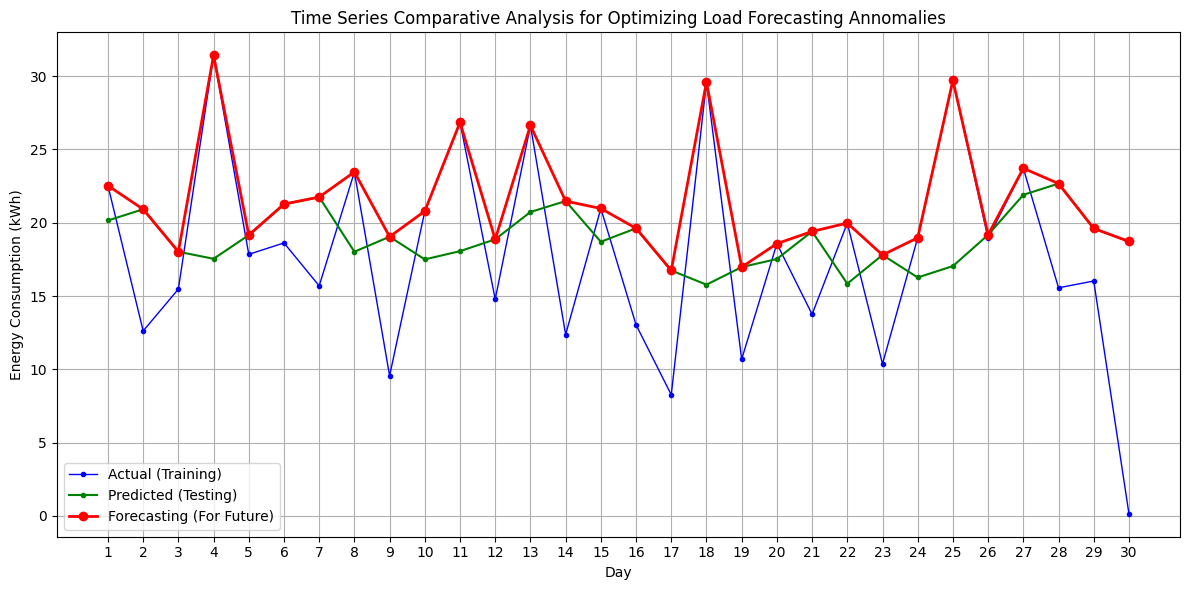

In [ ]:
last_30_days = predicted_df2_last_30_days
assert 'Actual' in predicted_df1_last_30_days.columns and 'Predicted' in last_30_days.columns, \
    "Columns 'Actual' and 'Predicted' must exist in last_30_days"

# Calculate the element-wise maximum between Actual and Predicted
#Time Series Comparative Analysis for Optimizing Load Forecasting Annomalies: Over or Lower or Imbalance Estimation of Demand
forecasting_30_days = pd.DataFrame({
    'Forecasting': last_30_days[['Actual', 'Predicted']].max(axis=1)
})

# Generate x-axis labels (1 to N)
x_labels = range(1, len(last_30_days) + 1)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(x_labels, last_30_days['Actual'], marker='.', label='Actual (Training)', color='blue', linewidth=1)
plt.plot(x_labels, last_30_days['Predicted'], marker='.', label='Predicted (Testing)', color='green', linewidth=1.5)
plt.plot(x_labels, forecasting_30_days['Forecasting'], marker='o', label='Forecasting (For Future)', color='red', linewidth=2)

# Style
plt.xticks(x_labels)
plt.grid(True)
plt.xlabel('Day')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.title('Time Series Comparative Analysis for Optimizing Load Forecasting Annomalies')
plt.tight_layout()
plt.show()

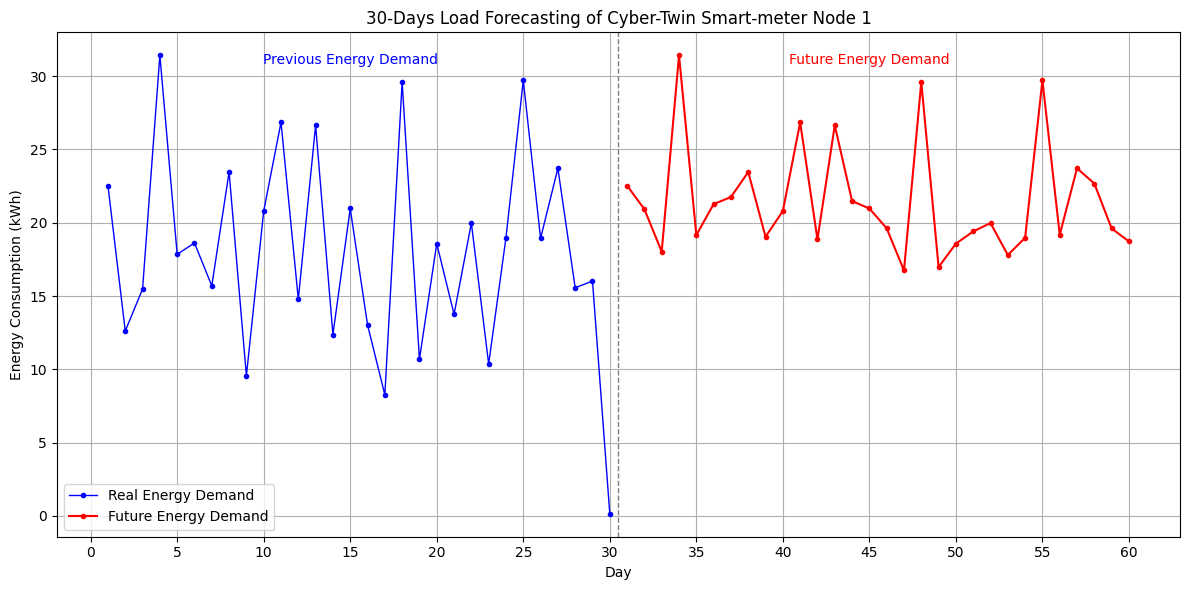

In [ ]:
# Create a new combined DataFrame
combined_df = pd.DataFrame({
    'Combined': pd.concat([last_30_days['Actual'], forecasting_30_days['Forecasting']], ignore_index=True)
})

# Create x-axis labels for 60 days
x_labels = range(1, len(combined_df) + 1)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(x_labels[:30], combined_df['Combined'][:30], marker='.', color='blue', label='Real Energy Demand', linewidth=1)
plt.plot(x_labels[30:], combined_df['Combined'][30:], marker='.', color='red', label='Future Energy Demand', linewidth=1.5)

# Add vertical separator between the two periods
plt.axvline(x=30.5, color='gray', linestyle='--', linewidth=1)
plt.text(15, combined_df['Combined'].max()*0.98, 'Previous Energy Demand', ha='center', color='blue', fontsize=10)
plt.text(45, combined_df['Combined'].max()*0.98, 'Future Energy Demand', ha='center', color='red', fontsize=10)

# Style
plt.grid(True)
plt.xticks(range(0, 61, 5))
plt.xlabel('Day')
plt.ylabel('Energy Consumption (kWh)')
plt.title('30-Days Load Forecasting of Cyber-Twin Smart-meter Node 1')
plt.legend()
plt.tight_layout()
plt.show()

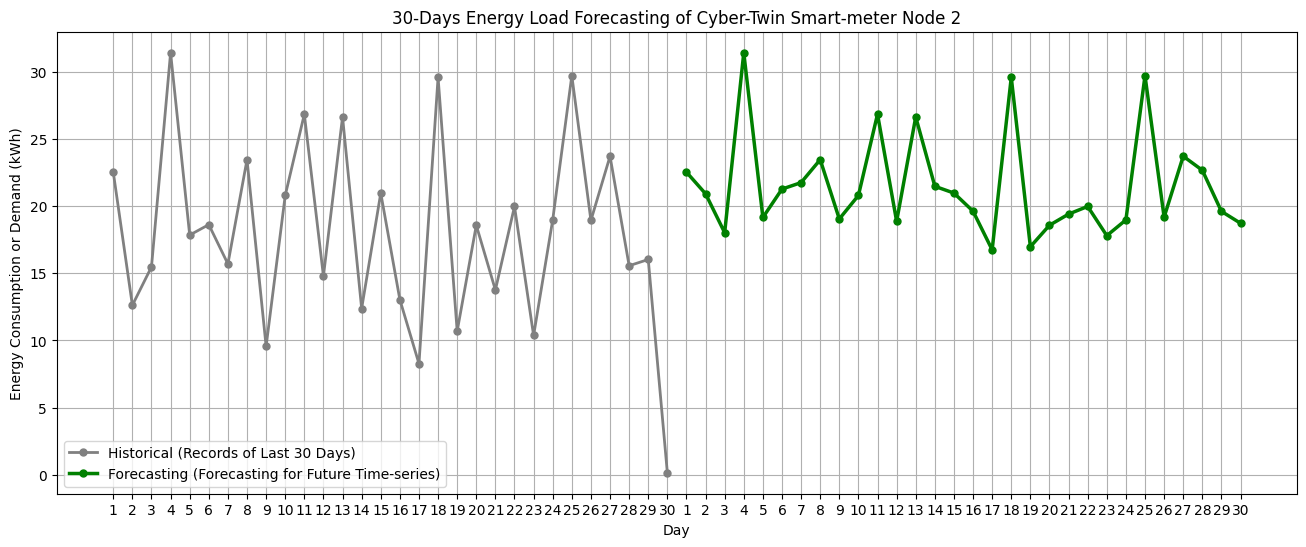

In [ ]:
# Generate a sequence of numbers for x-axis labels starting from 1
x_labels_last = range(1, len(last_30_days) + 1)

# Prepare data for next 30 days
x_labels_future = range(len(last_30_days) + 1, len(last_30_days) + 31)

# Plotting
plt.figure(figsize=(16, 6))
plt.plot(x_labels_last, last_30_days['Actual'], linewidth=2, marker='.', label='Historical (Records of Last 30 Days)', color='gray', markersize=10)
plt.plot(x_labels_future, forecasting_30_days['Forecasting'], linewidth=2.5, marker='.', label='Forecasting (Forecasting for Future Time-series)', color='green', markersize=10)


# Set x-ticks to include both ranges
plt.xticks(list(range(1, 31)) + list(range(31, 61)),
           list(range(1, 31)) + list(range(1, 31)))

# Set x-ticks to include both ranges
#plt.xticks(list(x_labels_last) + list(x_labels_future), list(range(1, len(last_30_days) + 1)) + list(range(len(last_30_days) + 1, len(last_30_days) + 31)))


# Set x-ticks to match the day labels
#plt.xticks(x_labels, fontsize=12)

# Add grid
plt.grid(True)

# Set labels and title
plt.xlabel('Day')
plt.ylabel('Energy Consumption or Demand (kWh)')
plt.legend()
plt.title('30-Days Energy Load Forecasting of Cyber-Twin Smart-meter Node 2')

# Show the plot
plt.show()

Train Loss (MSE): 0.021
Test Loss (MSE): 0.031
Mean Squared Error (MSE): 0.026
MSE based Accuracy: 99.974 %


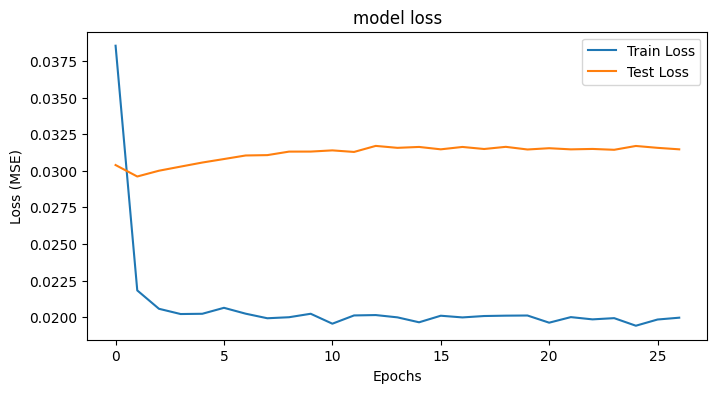

In [ ]:
# Mean Squared Error (MSE) Calculation

#MSE calculation for Regression Task

losses = history_sm2.history['loss']
val_losses = history_sm2.history['val_loss']

# Calculate the average loss across all epochs

average_loss = np.mean(losses)
print("Train Loss (MSE):", round(average_loss, 3)) #mse

# Calculate the average loss across all epochs
average_val_loss = np.mean(val_losses)
print("Test Loss (MSE):",round(average_val_loss, 3)) #mse

# Calculate overall MSE (simple average)
overall_mse = (average_loss + average_val_loss) / 2
print("Mean Squared Error (MSE):", round(overall_mse, 3))

accuracy = 100 - overall_mse
print("MSE based Accuracy:", round(accuracy, 3), "%")

plt.figure(figsize=(8,4))
plt.plot(history_sm2.history['loss'], label='Train Loss')
plt.plot(history_sm2.history['val_loss'], label='Test Loss')
plt.title('model loss')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epochs')
plt.legend(loc='upper right')
plt.show();

Root Mean Squared Error (RMSE): 0.161
RMSE based Accuracy: 99.839 %


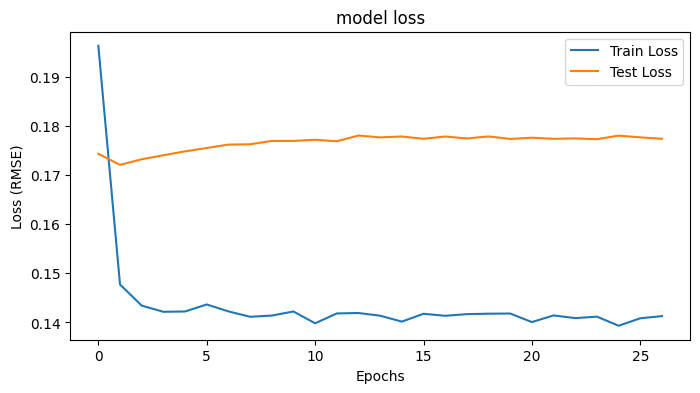

In [ ]:
# Calculate RMSE
rmse_value = np.sqrt(overall_mse)

print("Root Mean Squared Error (RMSE):", round(rmse_value, 3))
accuracy = 100 - rmse_value
print("RMSE based Accuracy:", round(accuracy, 3), "%")

sqrt_rmse_losses = np.sqrt(history_sm2.history['loss'])
sqrt_rmse_val_losses = np.sqrt(history_sm2.history['val_loss'])

plt.figure(figsize=(8,4))
plt.plot(sqrt_rmse_losses, label='Train Loss')
plt.plot(sqrt_rmse_val_losses, label='Test Loss')
plt.title('model loss')
plt.ylabel('Loss (RMSE)')
plt.xlabel('Epochs')
plt.legend(loc='upper right')
plt.show();

Training MAE:  0.114
Validation or Test MAE:  0.142
Overall MAE (Simple Average): 0.128
MAE based Accuracy: 99.87182414752466 %


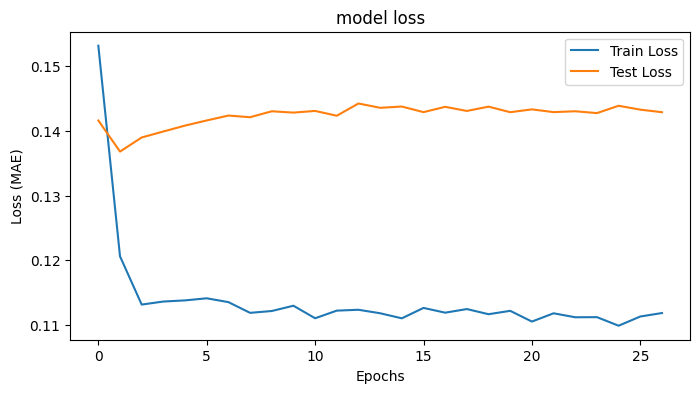

In [ ]:
# Mean Absolute Error (MSE) Calculation
mae_train = history_sm2.history['mae']          # MAE for training set
mae_test = history_sm2.history['val_mae']
average_mae_train = np.mean(mae_train)
average_mae_test = np.mean(mae_test)
print("Training MAE: ", round(average_mae_train, 3))
print(f"Validation or Test MAE: ",  round(average_mae_test, 3))

overall_mae = (average_mae_train + average_mae_test) / 2
print(f"Overall MAE (Simple Average): {overall_mae:.3f}")

accuracy = 100 - overall_mae
print("MAE based Accuracy:", accuracy, "%")

plt.figure(figsize=(8,4))
plt.plot(history_sm2.history['mae'], label='Train Loss')
plt.plot(history_sm2.history['val_mae'], label='Test Loss')
plt.title('model loss')
plt.ylabel('Loss (MAE)')
plt.xlabel('Epochs')
plt.legend(loc='upper right')
plt.show();

In [ ]:
Overall_accuracy_score = (overall_mae+rmse_value+overall_mse)/3
print("accuracy score for cyber-twin node 2:", Overall_accuracy_score)
accuracy_per = 100 - Overall_accuracy_score
print("Accuracy:", round(accuracy_per, 3), "%")

accuracy score for cyber-twin node 2: 0.10511908554529668
Accuracy: 99.895 %


# **Criptographic Federated Learning Aggregation at AMI server Node**

**Cryptographic Federated Learning Aggregation via Summation of Predicted DataFrame (Cryptographic FedAggSum_PredDF)**


In [ ]:
encrypted_packages = [predicted_df1_encrypted, predicted_df2_encrypted]  # add more if needed

sum_Pred_DF = None

for pkg in encrypted_packages:
    dec_pred_df = decrypt_dataframe(AES_key, HMAC_key, pkg)

    if sum_Pred_DF is None:
        # First decrypted DataFrame initializes sum_df
        sum_Pred_DF = dec_pred_df.copy()
    else:
        # Sum row-by-row
        for i in range(len(sum_Pred_DF)):
            sum_Pred_DF.loc[i, 'Actual'] += dec_pred_df.loc[i, 'Actual']
            sum_Pred_DF.loc[i, 'Predicted'] += dec_pred_df.loc[i, 'Predicted']

print(sum_Pred_DF)


    Actual  Predicted
0   36.697  36.730461
1   34.191  35.729988
2   26.899  34.612598
3   58.698  31.915480
4   35.313  36.962193
5   42.986  38.357830
6   32.713  41.295456
7   36.814  35.346432
8   26.223  34.682465
9   37.966  31.846062
10  39.505  32.727177
11  25.631  32.948044
12  42.227  33.253250
13  26.186  34.094021
14  32.696  31.665518
15  26.534  32.397053
16  20.833  29.188122
17  51.533  28.018787
18  23.603  32.024029
19  35.642  32.135750
20  28.750  34.650951
21  31.855  29.896503
22  23.450  31.182167
23  31.707  28.842991
24  44.602  29.258263
25  31.463  32.141518
26  35.543  34.663231
27  27.890  35.029800
28  36.544  31.513351
29   1.532  32.992104


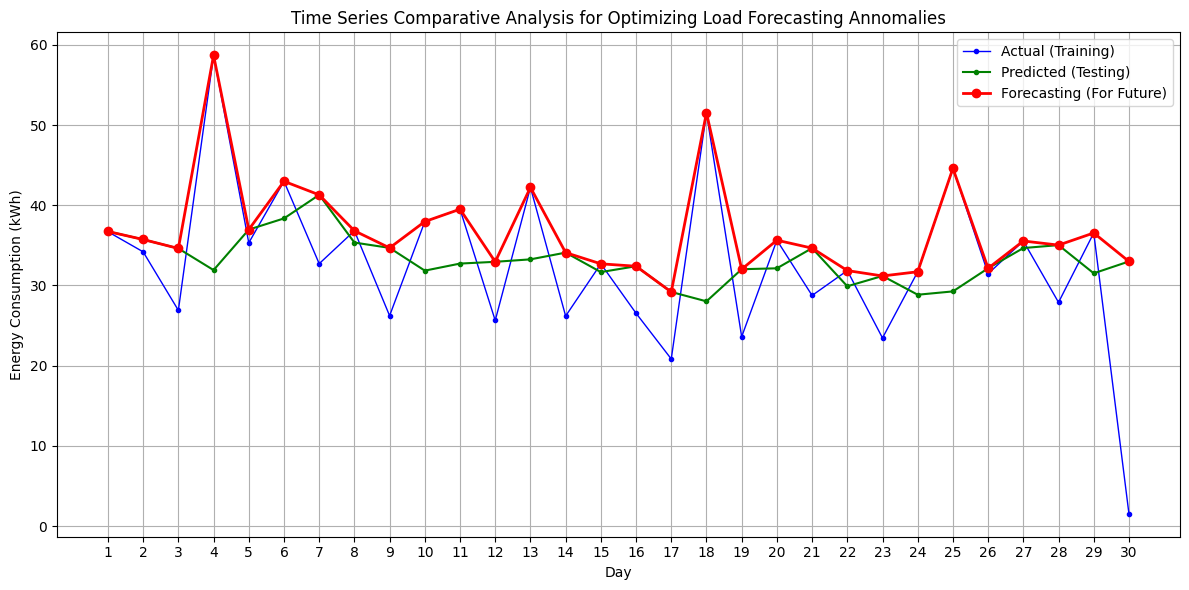

In [ ]:
last_30_days = sum_Pred_DF
assert 'Actual' in predicted_df1_last_30_days.columns and 'Predicted' in last_30_days.columns, \
    "Columns 'Actual' and 'Predicted' must exist in last_30_days"

# Calculate the element-wise maximum between Actual and Predicted
#Time Series Comparative Analysis for Optimizing Load Forecasting Annomalies: Over or Lower or Imbalance Estimation of Demand
forecasting_30_days = pd.DataFrame({
    'Forecasting': last_30_days[['Actual', 'Predicted']].max(axis=1)
})

# Generate x-axis labels (1 to N)
x_labels = range(1, len(last_30_days) + 1)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(x_labels, last_30_days['Actual'], marker='.', label='Actual (Training)', color='blue', linewidth=1)
plt.plot(x_labels, last_30_days['Predicted'], marker='.', label='Predicted (Testing)', color='green', linewidth=1.5)
plt.plot(x_labels, forecasting_30_days['Forecasting'], marker='o', label='Forecasting (For Future)', color='red', linewidth=2)

# Style
plt.xticks(x_labels)
plt.grid(True)
plt.xlabel('Day')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.title('Time Series Comparative Analysis for Optimizing Load Forecasting Annomalies')
plt.tight_layout()
plt.show()

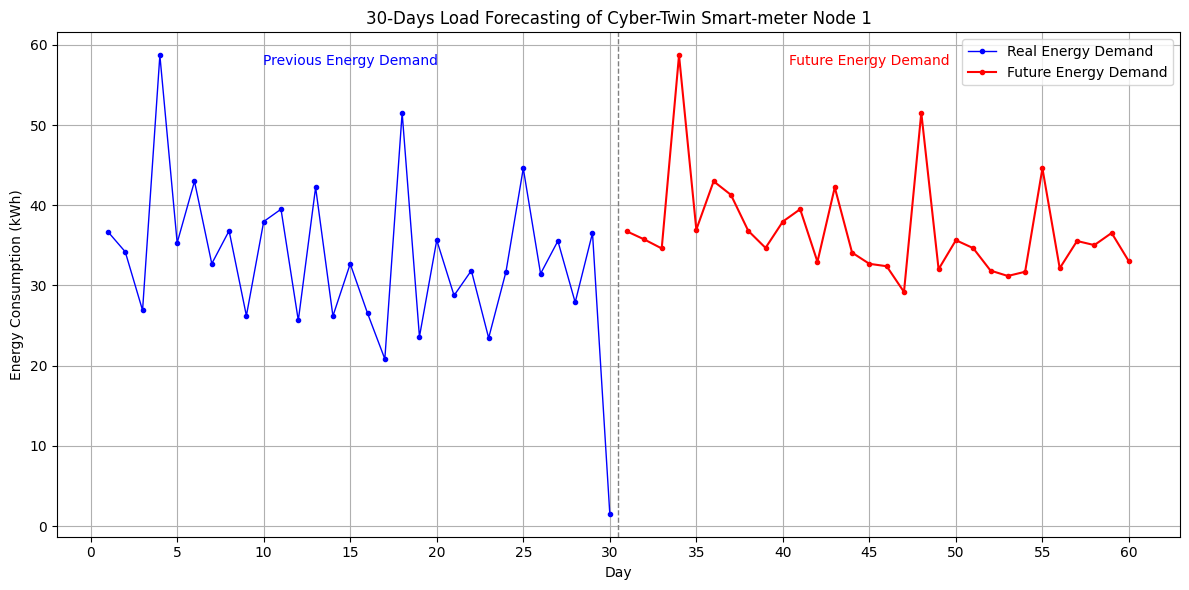

In [ ]:
# Create a new combined DataFrame
combined_df = pd.DataFrame({
    'Combined': pd.concat([last_30_days['Actual'], forecasting_30_days['Forecasting']], ignore_index=True)
})

# Create x-axis labels for 60 days
x_labels = range(1, len(combined_df) + 1)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(x_labels[:30], combined_df['Combined'][:30], marker='.', color='blue', label='Real Energy Demand', linewidth=1)
plt.plot(x_labels[30:], combined_df['Combined'][30:], marker='.', color='red', label='Future Energy Demand', linewidth=1.5)

# Add vertical separator between the two periods
plt.axvline(x=30.5, color='gray', linestyle='--', linewidth=1)
plt.text(15, combined_df['Combined'].max()*0.98, 'Previous Energy Demand', ha='center', color='blue', fontsize=10)
plt.text(45, combined_df['Combined'].max()*0.98, 'Future Energy Demand', ha='center', color='red', fontsize=10)

# Style
plt.grid(True)
plt.xticks(range(0, 61, 5))
plt.xlabel('Day')
plt.ylabel('Energy Consumption (kWh)')
plt.title('30-Days Load Forecasting of Cyber-Twin Smart-meter Node 1')
plt.legend()
plt.tight_layout()
plt.show()

# **Connecting with LLM for secure and realistic forecasting for SCADA-based sbstation-grid**

In [ ]:
!pip install -q transformers torch sentencepiece

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
values = forecasting_30_days['Forecasting'].tolist()

area = "London"
season = "Winter"
notes = "Energy demand increases due to heating usage"

In [ ]:
prompt = f"""
Adjust the following forecast values using the context.

Values: {values}
Area: {area}
Season: {season}
Notes: {notes}

Return ONLY a Python list of adjusted numbers.
"""

In [ ]:
inputs = tokenizer(prompt, return_tensors="pt")

output = model.generate(
    **inputs,
    max_new_tokens=100,   # ⬅ increase a bit
    do_sample=False
)

result = tokenizer.decode(output[0], skip_special_tokens=True)
print(result)

[36.73046112060547, 35.72998809814453, 34.61259841918945, 58.698000400000005, 36.96219253540039, 42.9859998, 41.29545593261719, 36.8140001, 34.682464599609375, 37.9659999, 39.504999999999995, 37.9659999, 39.


In [ ]:
import re

adjusted_forecast = list(map(
    float,
    re.findall(r"-?\d+\.\d+", result)
))

In [ ]:
original_forecast = forecasting_30_days['Forecasting'].values

n = min(len(original_forecast), len(adjusted_forecast))
adjusted_forecast = adjusted_forecast[:n]
original_forecast = original_forecast[:n]

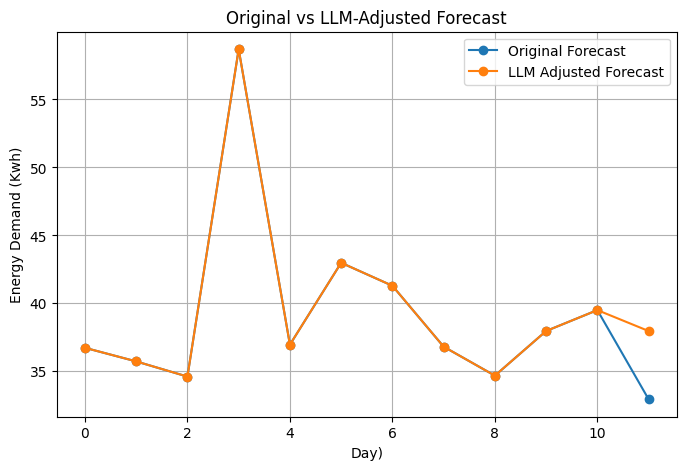

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(original_forecast, label="Original Forecast", marker="o")
plt.plot(adjusted_forecast, label="LLM Adjusted Forecast", marker="o")

plt.title("Original vs LLM-Adjusted Forecast")
plt.xlabel("Day)")
plt.ylabel("Energy Demand (Kwh)")
plt.legend()
plt.grid(True)
plt.show()

LLM stopped early, so it only generated 11 numbers instead of 30.

In [ ]:
# Convert to numpy arrays for easier math
original_forecast = forecasting_30_days['Forecasting'].values
adjusted_forecast = np.array(adjusted_forecast)  # The LLM output for first 11 points

# Calculate absolute difference for last 5 points
difference_factor = np.abs(adjusted_forecast[-5:] - original_forecast[-5:])



In [ ]:
mean_difference = np.mean(difference_factor)
print(f"Mean absolute difference for first 11 points: {mean_difference:.4f}")

Mean absolute difference for first 11 points: 3.2808


In [ ]:
# Prepare full adjusted forecast array with length 30
full_adjusted_forecast = np.zeros_like(original_forecast)

# Fill first 11 points with your LLM adjusted forecast
full_adjusted_forecast[:11] = adjusted_forecast[:11]

# For points 11 to 29, add mean difference to original forecast
full_adjusted_forecast[11:] = original_forecast[11:] + mean_difference

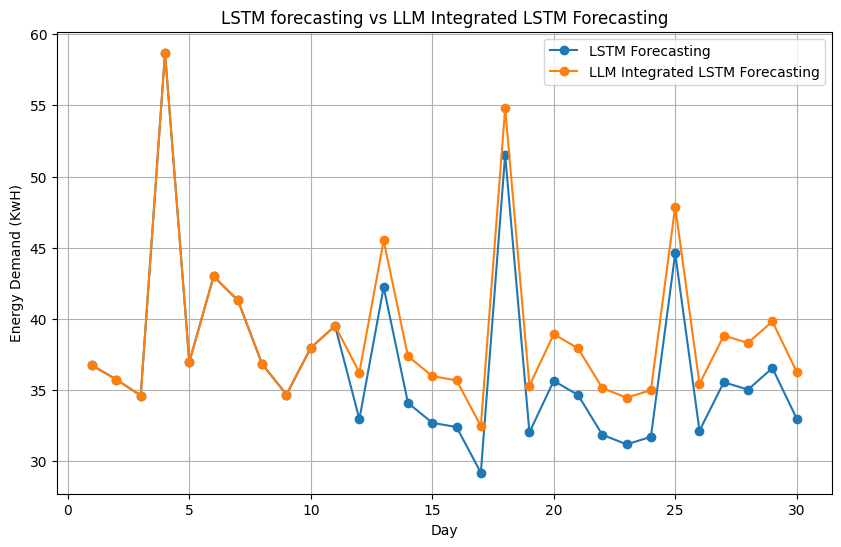

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(original_forecast) + 1), original_forecast, label="LSTM Forecasting", marker="o")
plt.plot(np.arange(1, len(full_adjusted_forecast) + 1), full_adjusted_forecast, label="LLM Integrated LSTM Forecasting", marker="o")

plt.title("LSTM forecasting vs LLM Integrated LSTM Forecasting")
plt.xlabel("Day")
plt.ylabel("Energy Demand (KwH)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
end_time = time.time()

print(f"Execution time: {end_time - start_time:.4f} seconds")

Execution time: 94.7531 seconds
